In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from T_method import LayeredStructure
from My_plotter import Plotter, Style
from Global_optimizer import my_json_load #Проверка связи

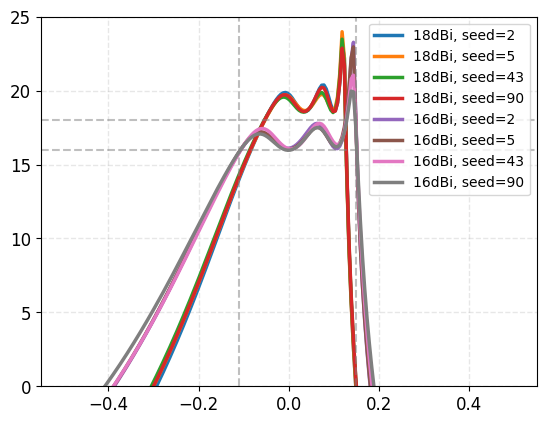

In [2]:
st = Style()
fig, ax = plt.subplots()
pl = Plotter(ax, st)
seeds = [2, 5, 43, 90]
df = np.linspace(-50, 50, 200)/100
for seed in seeds:
    path = Path(f"temp/de_seed_{seed}.json")
    data = my_json_load(path)
    alpha = data["best_alpha"]
    beta = data["best_beta"]
    structure = LayeredStructure(alpha, beta=beta)
    directivity = 10*np.log10(structure.directivity(df))
    pl.plot(df, directivity, label=f"18dBi, seed={seed}")
for seed in seeds:
    path = Path(f"temp/de_16_seed_{seed}.json")
    data = my_json_load(path)
    alpha = data["best_alpha"]
    beta = data["best_beta"]
    structure = LayeredStructure(alpha, beta=beta)
    directivity = 10*np.log10(structure.directivity(df))
    pl.plot(df, directivity, label=f"16dBi, seed={seed}")
pl.finalize()
pl.set_ylim((0, 25))
ax.axhline(18, color='gray', linestyle='--', alpha=0.5)
ax.axhline(16, color='gray', linestyle='--', alpha=0.5)
ax.axvline(-0.11, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0.15, color='gray', linestyle='--', alpha=0.5)
plt.show()

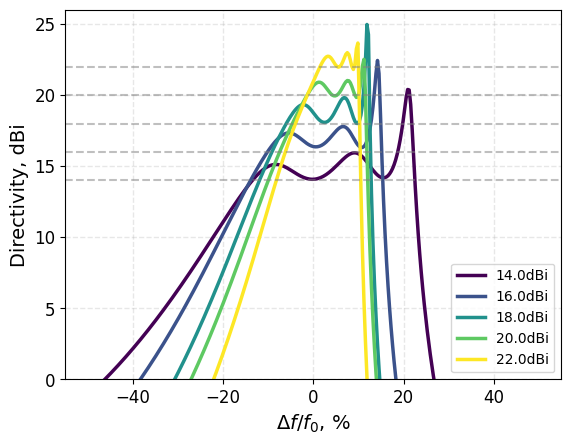

In [3]:
st = Style()
fig, ax = plt.subplots()
pl = Plotter(ax, st)
widths = []
thress = [14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0][::2]
pl.set_p(thress)
df = np.linspace(-50, 50, 300)/100
for thr in thress:
    path = Path(f"kz/de_{thr}_seed_90.json")
    data = my_json_load(path)
    alpha = data["best_alpha"]
    beta = data["best_beta"]
    structure = LayeredStructure(alpha, beta=beta)
    directivity = 10*np.log10(structure.directivity(df))
    l = 0
    while directivity[l] < thr:
        l += 1
    r = len(directivity)-1
    while directivity[r] < thr:
        r -= 1
    width = df[r] - df[l]
    widths.append(width)
    pl.multiple_plot(df*100, directivity, thr, label=f"{thr}dBi")
pl.set_ylim((0, 26))
for thr in thress:
    ax.axhline(thr, color='gray', linestyle='--', alpha=0.5)
pl.set_xlabel(r'$\Delta f/f_0$, %')
pl.set_ylabel('Directivity, dBi')
pl.finalize()
plt.show()

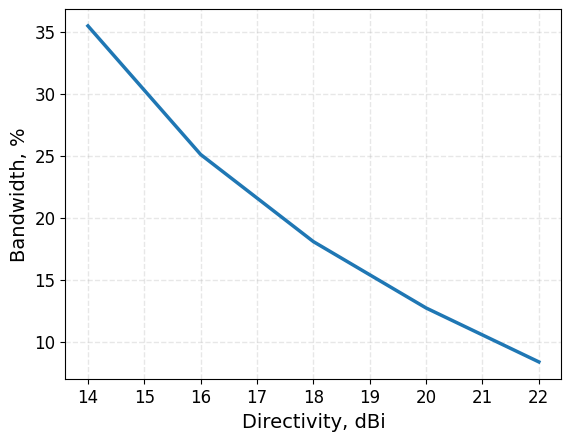

In [4]:
st = Style()
fig, ax = plt.subplots()
pl = Plotter(ax, st)
pl.plot(thress, np.array(widths)*100)
pl.set_xlabel('Directivity, dBi')
pl.set_ylabel(r'Bandwidth, %')
pl.finalize()
plt.show()

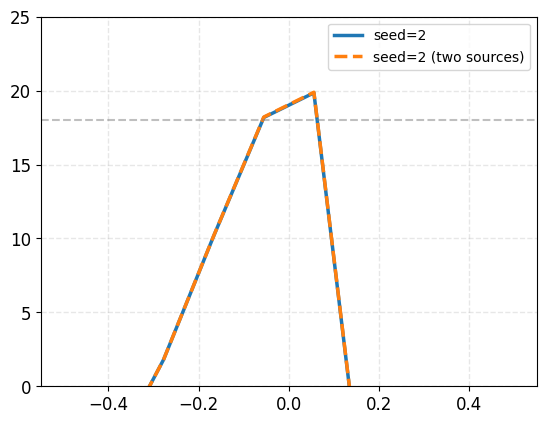

In [5]:
st = Style()
fig, ax = plt.subplots()
pl = Plotter(ax, st)
seeds = [2]
df = np.linspace(-50, 50, 10)/100
for seed in seeds:
    path = Path(f"different_seeds/test_local_post_de_seed_{seed}.json")
    data = my_json_load(path)
    alpha = data["best_alpha"]
    beta = data["best_beta"]
    structure = LayeredStructure(alpha, beta=beta)
    directivity = 10*np.log10(structure.directivity(df))
    directivity2 = 10*np.log10(structure.directivity_two_sources(df))
    pl.plot(df, directivity, label=f"seed={seed}")
    pl.plot(df, directivity2, linestyle='--', label=f"seed={seed} (two sources)")
pl.finalize()
pl.set_ylim((0, 25))
ax.axhline(18, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
st = Style()
fig, ax = plt.subplots()
pl = Plotter(ax, st)
seeds = [2]
df = np.linspace(-50, 50, 200)/100
for seed in seeds:
    path = Path(f"temp/de_16_smallbounds_seed_{seed}.json")
    data = my_json_load(path)
    alpha = data["best_alpha"]
    beta = data["best_beta"]
    structure = LayeredStructure(alpha, beta=beta)
    directivity = 10*np.log10(structure.directivity(df))
    pl.plot(df, directivity, label=f"16dBi, seed={seed}")
pl.finalize()
pl.set_ylim((0, 25))
ax.axhline(18, color='gray', linestyle='--', alpha=0.5)
ax.axhline(16, color='gray', linestyle='--', alpha=0.5)
ax.axvline(-0.11, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0.15, color='gray', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
for seed in seeds:
    path = Path(f"temp/de_16_seed_{seed}.json")
    data = my_json_load(path)
    print(f"seed={seed}, best_score={data['best_score']}")

In [ ]:
for seed in seeds:
    path = Path(f"different_seeds/test_local_post_de_seed_{seed}.json")
    data = my_json_load(path)
    print(f"seed={seed}, best_score={data['best_score']}")

In [ ]:
for seed in seeds:
    path = Path(f"different_seeds/test_de_seed_{seed}.json")
    data = my_json_load(path)
    print(f"seed={seed}, alpha={data['best_alpha']}")

In [ ]:
for seed in seeds:
    path = Path(f"different_seeds/test_local_post_de_seed_{seed}.json")
    data = my_json_load(path)
    print(f"seed={seed}, alpha={data['best_alpha']}")

In [ ]:
for seed in seeds:
    path = Path(f"different_seeds/test_de_seed_{seed}.json")
    data = my_json_load(path)
    print(f"seed={seed}, beta={data['best_beta']}")

In [ ]:
for seed in seeds:
    path = Path(f"different_seeds/test_local_post_de_seed_{seed}.json")
    data = my_json_load(path)
    print(f"seed={seed}, beta={data['best_beta']}")

In [ ]:
print([(0.1, 7.0)]*5)